In [1]:
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scanpy as sc
import scipy.stats as st
import random
large_data_dir = gf_utils.large_data_dir
matplotlib.rcParams['pdf.fonttype'] = 42


In [2]:
adata = sc.read_h5ad(large_data_dir + 'MPN_WTA/Integrated_MPN_scvi_genotyped_nb.h5ad')
adata = adata[adata.obs['cell_type'] != 'Monocyte/Platelet doublet (non-HSPC)']


In [3]:
MPN_count = pd.DataFrame(adata.obsm['genotypes'][['JAK2 c.1849G>T_high_confidence_counts']]).fillna(0).sum(axis=1) ### include all for JAK2

MPN_count = pd.DataFrame(MPN_count, columns = ['counts'])
MPN_count.index = MPN_count.index.str.replace('4-plex','4plex')
MPN_count.index = MPN_count.index.str.replace('1-plex','1plex')

MPN_count['sample'] = MPN_count.index.str.split('-').str[-1]


/tmp/ipykernel_112438/1445806120.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  GIFT_props = (MPN_count.groupby('sample').apply(lambda x: (x['counts'] > 0).sum() / len(x)))


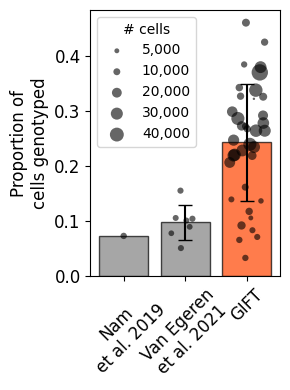

In [4]:
GIFT_n_cells = MPN_count.groupby('sample').size()
van_egeren_n_cells = [7868,7349,7091,6732,7472,7911,7704]
GoT_n_cells = [8475]

GIFT_props = (MPN_count.groupby('sample').apply(lambda x: (x['counts'] > 0).sum() / len(x)))
van_egeren_props = pd.Series([0.104219624, 0.100966118, 0.089550134, 0.077837195, 0.105594218, 0.155226899, 0.050882658])
GoT_props = pd.Series([0.073])

# Create the plot
fig, ax = plt.subplots(figsize=(3,4))

# Create bar plot with error bars
x_labels = ['Nam\net al. 2019','Van Egeren\net al. 2021', 'GIFT']
x_pos = np.arange(len(x_labels))

bars = ax.bar(x_pos, [GoT_props.mean(), van_egeren_props.mean(), GIFT_props.mean()], yerr=[GoT_props.std(), van_egeren_props.std(), GIFT_props.std()], capsize=5, alpha=0.7, 
              color=['grey','grey','orangered'],edgecolor='black')

size_scale = 400
jitter_scale = 0.3
for patient, x_loc in zip(GoT_props, [0 + random.uniform(-jitter_scale, jitter_scale) for _ in range(len(GoT_props))]):
    ax.scatter(0, patient, s = GoT_n_cells[0]/size_scale, color='black', alpha=0.6, edgecolor='none')
for patient, x_loc in zip(van_egeren_props, [1 + random.uniform(-jitter_scale, jitter_scale) for _ in range(len(van_egeren_props))]):
    ax.scatter(x_loc, patient, s = van_egeren_n_cells[van_egeren_props.tolist().index(patient)]/size_scale, color='black', alpha=0.6, edgecolor='none')
# for patient in GIFT_props:
for patient, x_loc in zip(GIFT_props, [2 + random.uniform(-jitter_scale, jitter_scale) for _ in range(len(GIFT_props))]):
    ax.scatter(x_loc, patient, s = GIFT_n_cells[GIFT_props[GIFT_props == patient].index.unique()]/size_scale, color='black', alpha=0.6, edgecolor='none')

# Add legend for point sizes
legend_sizes = [5000, 10000, 20000, 30000, 40000]
legend_labels = [f'{s:,}' for s in legend_sizes]
legend_handles = [plt.scatter([], [], s=s/size_scale, color='black', alpha=0.6, edgecolor='none') for s in legend_sizes]
legend = ax.legend(legend_handles, legend_labels, title='# cells', loc='upper left', frameon=True, fontsize=10, title_fontsize=10)

ax.set_ylabel('Proportion of\ncells genotyped', size=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha='center', size=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()

plt.savefig('../plots/JAK2_MPN_capture_vs_GoT.pdf', bbox_inches='tight')


In [5]:
st.mannwhitneyu(GIFT_props, van_egeren_props.tolist(), alternative='greater')

MannwhitneyuResult(statistic=227.0, pvalue=0.00042945605607933577)

In [6]:
st.mannwhitneyu(GIFT_props, GoT_props.tolist() + van_egeren_props.tolist(), alternative='greater')

MannwhitneyuResult(statistic=261.0, pvalue=0.0001610414542915961)